# Experiences complementaires (Fashion-MNIST)

Meme notebook que l'original, rejoue sur T-shirt/top vs Shirt (Fashion-MNIST). Toujours trois
questions :

1. est-ce que mes resultats bougent beaucoup si je change juste la graine aleatoire ?
2. est-ce que le pre-entrainement aide encore quand on a tres peu de labels ?
3. est-ce que le pre-entrainement sert vraiment, compare a un encodeur qu'on n'a jamais entraine ?

Le notebook est autonome : je recopie le modele et les fonctions du notebook 02 pour qu'il
tourne tout seul. Sur ce dataset plus gros, ca prend nettement plus que "quelques minutes" sur
CPU (plutot un quart d'heure).

In [1]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)


# meme decoupage que le notebook 02 : 60% train, 20% val, 20% test
data = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
X_all, y_all = data.data, data.target.astype(int)
mask = np.isin(y_all, [0, 6])
X = X_all[mask]
y = (y_all[mask] == 6).astype(int)  # 0 = T-shirt/top, 1 = Shirt

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=123, stratify=y_trainval)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Xtr_t = torch.from_numpy(X_train).float()
Xte_t = torch.from_numpy(X_test).float()
yte_t = torch.from_numpy(y_test).long()

# le pre-entrainement voit tout le train mais sans les labels (c'est ca l'auto-supervise)
pretrain_loader = DataLoader(TensorDataset(Xtr_t), batch_size=128, shuffle=True)
# le test sert juste a evaluer, jamais a entrainer
test_loader = DataLoader(TensorDataset(Xte_t, yte_t), batch_size=128, shuffle=False)


def make_clf_loader(X_arr, y_arr):
    # petit utilitaire : fabrique un loader d'entrainement supervise a partir de numpy.
    # utile quand on ne garde qu'une partie des labels (etude 2)
    xb = torch.from_numpy(np.asarray(X_arr)).float()
    yb = torch.from_numpy(np.asarray(y_arr)).long()
    return DataLoader(TensorDataset(xb, yb), batch_size=128, shuffle=True)

## Le modele et les fonctions de base

Rien de neuf ici, c'est repris du notebook 02 : le meme auto-encodeur (784 -> 256 -> 64 ->
latent), plus trois fonctions (pre-entrainement, entrainement de la tete de classif, evaluation
sur le test).

In [2]:
# auto-encodeur : encodeur 784 -> 256 -> 64 -> latent, decodeur latent -> 64 -> 256 -> 784
class Encodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256), nn.LeakyReLU(),
            nn.Linear(256, 64), nn.LeakyReLU(),
            nn.Linear(64, latent_dim))
    def forward(self, x):
        return self.net(x)

class Decodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.LeakyReLU(),
            nn.Linear(64, 256), nn.LeakyReLU(),
            nn.Linear(256, 784))
    def forward(self, z):
        return self.net(z)

class AutoEncodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encodeur = Encodeur(latent_dim)
        self.decodeur = Decodeur(latent_dim)
    def forward(self, x):
        return self.decodeur(self.encodeur(x))

class Classifieur(nn.Module):
    # encodeur + petite tete. freeze=True => encodeur gele (linear probing),
    # freeze=False => tout s'entraine (full fine-tuning)
    def __init__(self, encodeur, latent_dim, freeze):
        super().__init__()
        self.encodeur = encodeur
        if freeze:
            for p in self.encodeur.parameters():
                p.requires_grad = False
        self.tete = nn.Sequential(
            nn.Linear(latent_dim, 8), nn.LeakyReLU(),
            nn.Linear(8, 2))
    def forward(self, x):
        return self.tete(self.encodeur(x))


def pretrain(latent_dim, epochs=80):
    # pre-entrainement non supervise : l'AE apprend juste a reconstruire les donnees
    ae = AutoEncodeur(latent_dim)
    opt = torch.optim.AdamW(ae.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()
    for _ in range(epochs):
        ae.train()
        for (xb,) in pretrain_loader:
            opt.zero_grad()
            loss_fn(ae(xb), xb).backward()
            opt.step()
    return ae

def train_clf(model, loader, epochs=80):
    # on n'entraine que les parametres non geles (pour le probing, ca fait juste la tete)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                            lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(set_to_none=True)
            loss_fn(model(xb), yb).backward()
            opt.step()
    return model

def test_scores(model):
    # renvoie le F1 macro et le ROC-AUC sur le jeu de test
    model.eval()
    yt, yp, pp = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb)
            pp.extend(torch.softmax(logits, dim=1)[:, 1].numpy())
            yp.extend(logits.argmax(dim=1).numpy())
            yt.extend(yb.numpy())
    yt, yp, pp = np.array(yt), np.array(yp), np.array(pp)
    return f1_score(yt, yp, average="macro"), roc_auc_score(yt, pp)

## Etude 1 : est-ce que les scores sont stables ?

Le probleme d'un seul run, c'est qu'on ne sait pas si le chiffre obtenu est representatif ou
juste un coup de chance lie a l'initialisation aleatoire. Ici je relance tout le pipeline
(pre-entrainement + probing + full fine-tuning) avec 5 graines differentes, et je regarde la
moyenne et l'ecart-type.

probing AUC  : 0.864 +/- 0.004
probing F1   : 0.791 +/- 0.006
full-ft AUC  : 0.941 +/- 0.003
full-ft F1   : 0.870 +/- 0.004


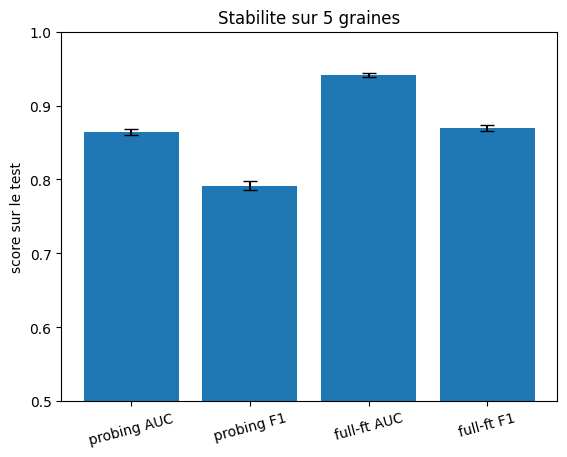

In [3]:
def run_once(seed, latent_dim=2):
    # un pipeline complet pour une graine donnee, renvoie les 4 scores
    set_seed(seed)
    ae = pretrain(latent_dim)   # meme AE de depart pour les deux regimes

    # linear probing : encodeur gele, on entraine juste la tete
    set_seed(seed)
    probe = Classifieur(copy.deepcopy(ae.encodeur), latent_dim, freeze=True)
    train_clf(probe, make_clf_loader(X_train, y_train))
    pf1, pauc = test_scores(probe)

    # full fine-tuning : memes poids de depart, mais rien n'est gele
    set_seed(seed)
    ft = Classifieur(copy.deepcopy(ae.encodeur), latent_dim, freeze=False)
    train_clf(ft, make_clf_loader(X_train, y_train))
    ff1, fauc = test_scores(ft)
    return [pauc, pf1, fauc, ff1]


SEEDS = [0, 1, 2, 3, 4]
arr = np.array([run_once(s) for s in SEEDS])

noms = ["probing AUC", "probing F1", "full-ft AUC", "full-ft F1"]
for i, nom in enumerate(noms):
    print(f"{nom:12s} : {arr[:, i].mean():.3f} +/- {arr[:, i].std():.3f}")

plt.bar(range(4), arr.mean(axis=0), yerr=arr.std(axis=0), capsize=5)
plt.xticks(range(4), noms, rotation=15)
plt.ylim(0.5, 1.0)
plt.ylabel("score sur le test")
plt.title("Stabilite sur 5 graines")
plt.savefig("figures/seeds_stability.png", dpi=130, bbox_inches="tight")
plt.show()

## Etude 2 : est-ce que le pre-entrainement aide quand on a peu de labels ?

L'idee : les labels coutent cher, mais les donnees brutes non. Donc on pre-entraine l'encodeur
sur TOUT le train sans labels (gratuit), et on n'utilise qu'une petite fraction des labels pour
entrainer la tete de classif. On compare a une regression logistique entrainee sur la meme
petite fraction.

labels   5%  ->  SSL+probing AUC 0.797  |  logreg AUC 0.889
labels  10%  ->  SSL+probing AUC 0.816  |  logreg AUC 0.878
labels  25%  ->  SSL+probing AUC 0.834  |  logreg AUC 0.870
labels  50%  ->  SSL+probing AUC 0.857  |  logreg AUC 0.883
labels 100%  ->  SSL+probing AUC 0.864  |  logreg AUC 0.912


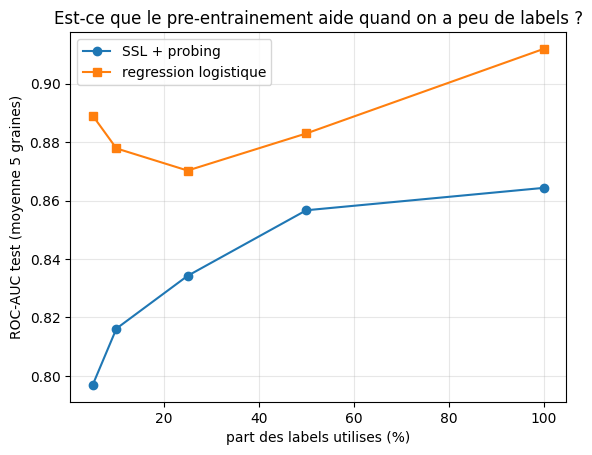

In [4]:
fracs = [0.05, 0.1, 0.25, 0.5, 1.0]

def subsample(frac, seed):
    # garde une fraction du train etiquete, en gardant les proportions des classes
    if frac >= 1.0:
        return X_train, y_train
    Xs, _, ys, _ = train_test_split(X_train, y_train, train_size=frac,
                                    stratify=y_train, random_state=seed)
    return Xs, ys

ssl_curve = {f: [] for f in fracs}
base_curve = {f: [] for f in fracs}

for seed in SEEDS:
    set_seed(seed)
    ae = pretrain(2)   # un seul pre-entrainement par graine, reutilise pour toutes les fractions
    for f in fracs:
        Xs, ys = subsample(f, seed)

        # cote pre-entrainement : encodeur gele + tete, entraines sur le sous-ensemble
        set_seed(seed)
        clf = Classifieur(copy.deepcopy(ae.encodeur), 2, freeze=True)
        train_clf(clf, make_clf_loader(Xs, ys))
        _, auc = test_scores(clf)
        ssl_curve[f].append(auc)

        # cote baseline : regression logistique sur exactement les memes donnees
        lr = LogisticRegression(max_iter=1000, class_weight="balanced")
        lr.fit(Xs, ys)
        base_curve[f].append(roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]))

ssl_mean = [np.mean(ssl_curve[f]) for f in fracs]
base_mean = [np.mean(base_curve[f]) for f in fracs]

for f, a, b in zip(fracs, ssl_mean, base_mean):
    print(f"labels {int(f*100):3d}%  ->  SSL+probing AUC {a:.3f}  |  logreg AUC {b:.3f}")

plt.plot([f * 100 for f in fracs], ssl_mean, "o-", label="SSL + probing")
plt.plot([f * 100 for f in fracs], base_mean, "s-", label="regression logistique")
plt.xlabel("part des labels utilises (%)")
plt.ylabel("ROC-AUC test (moyenne 5 graines)")
plt.title("Est-ce que le pre-entrainement aide quand on a peu de labels ?")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("figures/label_efficiency.png", dpi=130, bbox_inches="tight")
plt.show()

## Etude 3 : est-ce que le pre-entrainement sert vraiment ?

Je compare deux cas, avec la meme tete et le meme entrainement : un encodeur pre-entraine (gele)
contre un encodeur aux poids aleatoires (gele lui aussi, jamais pre-entraine). Sur plusieurs
graines pour eviter que l'ecart soit juste du bruit.

encodeur pre-entraine : AUC 0.864 +/- 0.004
encodeur aleatoire    : AUC 0.598 +/- 0.041
ecart moyen           : +0.267


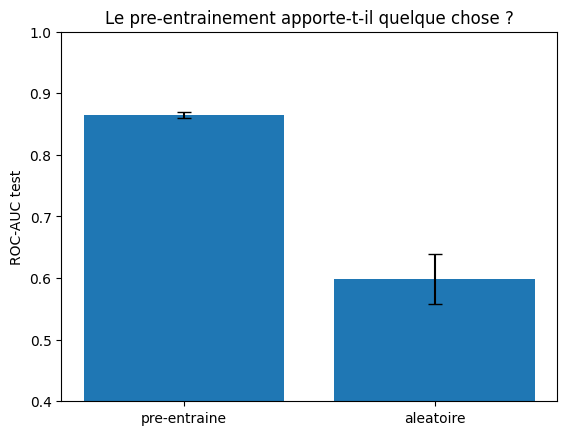

In [5]:
pre_scores, rnd_scores = [], []
for seed in SEEDS:
    set_seed(seed)
    ae = pretrain(2)

    #cas 1 : encodeur pre-entraine, gele
    set_seed(seed)
    clf_pre = Classifieur(copy.deepcopy(ae.encodeur), 2, freeze=True)
    train_clf(clf_pre, make_clf_loader(X_train, y_train))
    _, auc_pre = test_scores(clf_pre)
    pre_scores.append(auc_pre)

    #cas 2 : encodeur tout neuf (poids aleatoires), gele lui aussi
    set_seed(seed)
    enc_rnd = Encodeur(2)
    clf_rnd = Classifieur(enc_rnd, 2, freeze=True)
    train_clf(clf_rnd, make_clf_loader(X_train, y_train))
    _, auc_rnd = test_scores(clf_rnd)
    rnd_scores.append(auc_rnd)

pre_scores = np.array(pre_scores)
rnd_scores = np.array(rnd_scores)
print(f"encodeur pre-entraine : AUC {pre_scores.mean():.3f} +/- {pre_scores.std():.3f}")
print(f"encodeur aleatoire    : AUC {rnd_scores.mean():.3f} +/- {rnd_scores.std():.3f}")
print(f"ecart moyen           : {(pre_scores.mean() - rnd_scores.mean()):+.3f}")

plt.bar(["pre-entraine", "aleatoire"],
        [pre_scores.mean(), rnd_scores.mean()],
        yerr=[pre_scores.std(), rnd_scores.std()], capsize=5)
plt.ylim(0.4, 1.0)
plt.ylabel("ROC-AUC test")
plt.title("Le pre-entrainement apporte-t-il quelque chose ?")
plt.savefig("figures/ablation_pretrain.png", dpi=130, bbox_inches="tight")
plt.show()

## Ce que ces trois etudes apportent

**Stabilite.** Comme sur le cancer, les ecarts-types sont petits (probing AUC 0,864 +/- 0,004,
full-ft AUC 0,941 +/- 0,003) : les chiffres des autres notebooks sont fiables, pas des coups de
chance.

**Efficacite en labels.** Ici, la regression logistique bat le SSL + probing a *toutes* les
fractions de labels (par exemple 0,889 contre 0,797 a 5 %, 0,912 contre 0,864 a 100 %) — le
meme resultat surprenant que sur le cancer, mais pour une raison differente. Cette etude fixe le
latent a 2 (comme l'etude originale), et le notebook 02 a deja montre que le linear probing a
cette dimension est justement le pire cas (AUC 0,867 en latent 2 contre 0,931 en latent 16). Le
probing a latent 2 perd donc autant a cause du goulot d'etranglement que du manque de labels :
avec plus de capacite latente ou en fine-tuning complet (0,941, notebook 02), le pre-entrainement
repasse devant la regression logistique. La lecon n'est plus "le pre-entrainement ne sert a rien
en faible regime de labels" mais "un encodeur gele trop etroit ne sert a rien, quel que soit le
nombre de labels".

**Le pre-entrainement sert-il vraiment ?** Oui, sans ambiguite : un encodeur jamais entraine
retombe a 0,598 +/- 0,041 (proche du hasard, et bien plus instable), contre 0,864 +/- 0,004 pour
l'encodeur pre-entraine — un ecart de +0,267, du meme ordre que sur le cancer (+0,302). Le
pre-entrainement capture donc une vraie structure utile ; le probing reste en dessous des
baselines par manque de capacite latente, pas par manque de signal appris.